<a href="https://colab.research.google.com/github/ThePhaniVemuri/keylogger_ML_pipeline/blob/main/keylogger_ml_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Keylogger Detection - End-to-End ML Pipeline

Load Data → Memory Optimization → EDA → Missing Value Analysis → Duplicate Removal →
Timestamp Features → IP Frequency Encoding → Label Encoding → Feature Selection →
Train/Test Split → Random Forest → Extra Trees → XGBoost → Stacking Ensemble →
Cross Validation → Evaluation → Feature Importance → Save Model → Streamlit

In [ ]:
# INSTALLS
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost joblib shap streamlit

import os
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
)

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from xgboost import XGBClassifier


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 43.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
)

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from xgboost import XGBClassifier

# Paths / config
CSV_PATH = '/content/drive/MyDrive/Datasets-for-AI,ML,DL/Keylogger_Detection.csv'
MODEL_DIR = 'artifacts'
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_PATH = os.path.join(MODEL_DIR, 'keylogger_stacking_model.joblib')
META_PATH = os.path.join(MODEL_DIR, 'preprocessor.joblib')

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 2 # Reduced for faster cross-validation

print('Dataset path:', CSV_PATH)
df = pd.read_csv(CSV_PATH, low_memory=False)
print('Raw shape:', df.shape)
print('Target distribution (Class):')
print(df['Class'].value_counts(dropna=False))

Dataset path: /content/drive/MyDrive/Datasets-for-AI,ML,DL/Keylogger_Detection.csv
Raw shape: (523617, 86)
Target distribution (Class):
Class
Benign       308813
Keylogger    214804
Name: count, dtype: int64


In [ ]:
# 1) Memory Optimization
def reduce_mem_usage(input_df: pd.DataFrame) -> pd.DataFrame:
    df_ = input_df.copy()
    for col in df_.columns:
        col_type = df_[col].dtype
        if pd.api.types.is_numeric_dtype(col_type):
            c_min = df_[col].min()
            c_max = df_[col].max()
            if pd.api.types.is_integer_dtype(col_type):
                if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                    df_[col] = df_[col].astype(np.int8)
                elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                    df_[col] = df_[col].astype(np.int16)
                elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                    df_[col] = df_[col].astype(np.int32)
                else:
                    df_[col] = df_[col].astype(np.int64)
            else:
                df_[col] = pd.to_numeric(df_[col], downcast='float')
        elif col_type == 'object':
            df_[col] = df_[col].astype(str).str.strip()
    return df_

df = reduce_mem_usage(df)
print('After memory optimization:', df.shape)


After memory optimization: (523617, 86)


Missing values (top 20):
 Active Min                 22
 Active Std                 22
 Idle Min                   22
 Idle Max                   22
Idle Mean                   22
 Active Max                 22
 Idle Std                   22
Init_Win_bytes_forward      20
 Subflow Bwd Packets        20
 Init_Win_bytes_backward    20
 Avg Bwd Segment Size       20
 Fwd Avg Packets/Bulk       20
Fwd Avg Bytes/Bulk          20
 Subflow Fwd Bytes          20
 Fwd Header Length.1        20
 Subflow Bwd Bytes          20
 Average Packet Size        20
 Down/Up Ratio              20
 Fwd Avg Bulk Rate          20
Bwd Avg Bulk Rate           20
dtype: int64


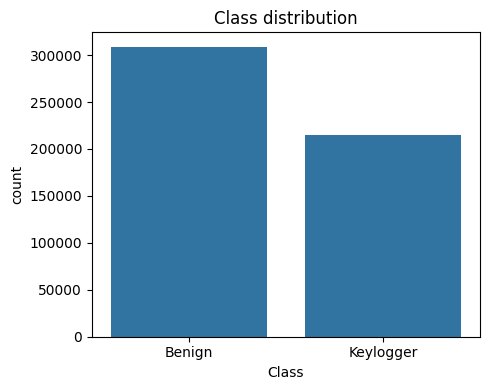

In [ ]:
# 2) EDA (lightweight)
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print('Missing values (top 20):')
print(missing.head(20))

plt.figure(figsize=(5,4))
sns.countplot(x='Class', data=df)
plt.title('Class distribution')
plt.tight_layout()
plt.show()


In [ ]:
# 3) Duplicate Removal
initial_rows = len(df)
df = df.drop_duplicates()
print('Removed duplicates:', initial_rows - len(df))


Removed duplicates: 0


In [ ]:
# 4) Feature Engineering: Timestamp + IP Frequency
class TimestampFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, timestamp_col=' Timestamp'):
        self.timestamp_col = timestamp_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_ = X.copy()
        if self.timestamp_col in X_.columns:
            ts = X_[self.timestamp_col].astype(str).str.strip()
            dt = pd.to_datetime(ts, errors='coerce')
            X_['Timestamp_year'] = dt.dt.year
            X_['Timestamp_month'] = dt.dt.month
            X_['Timestamp_day'] = dt.dt.day
            X_['Timestamp_hour'] = dt.dt.hour
            X_['Timestamp_minute'] = dt.dt.minute
            X_['Timestamp_dayofweek'] = dt.dt.dayofweek
        return X_

class IPFrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, ip_cols=None):
        self.ip_cols = ip_cols or [' Source IP', ' Destination IP']
        self.freq_maps_ = {}

    def fit(self, X, y=None):
        X_ = X.copy()
        for c in self.ip_cols:
            s = X_[c].astype(str).str.strip()
            self.freq_maps_[c] = s.value_counts(dropna=False).to_dict()
        return self

    def transform(self, X):
        X_ = X.copy()
        for c in self.ip_cols:
            s = X_[c].astype(str).str.strip()
            fmap = self.freq_maps_.get(c, {})
            X_[f'{c}_freq'] = s.map(fmap).astype(float).fillna(0.0)
        return X_

TARGET_COL = 'Class'
timestamp_col = ' Timestamp'
ip_cols = [' Source IP', ' Destination IP']

fe = Pipeline(steps=[
    ('ts', TimestampFeatures(timestamp_col=timestamp_col)),
    ('ipfreq', IPFrequencyEncoder(ip_cols=ip_cols)),
])

df_fe = fe.fit_transform(df)
X = df_fe.drop(columns=[TARGET_COL])
y = df_fe[TARGET_COL].astype(str)

categorical_cols = [c for c in X.columns if X[c].dtype == 'object']
numeric_cols = [c for c in X.columns if c not in categorical_cols]


In [ ]:
# 5) Preprocessing (Missing Value + Label Encoding)
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ],
    remainder='drop',
)


In [ ]:
# 6) Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# 7) Label Encoding to 0/1 for XGBoost
label_map = {c: i for i, c in enumerate(sorted(y.unique()))}
y_train_num = y_train.map(label_map)
y_test_num = y_test.map(label_map)


In [ ]:
# 8) Models: Random Forest, Extra Trees, XGBoost
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced') # Reduced n_estimators
et = ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced') # Reduced n_estimators
xgb = XGBClassifier(
    n_estimators=100, # Reduced n_estimators
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective='binary:logistic',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
)

stack = StackingClassifier(
    estimators=[('rf', rf), ('et', et), ('xgb', xgb)],
    final_estimator=XGBClassifier(
        n_estimators=50, # Reduced n_estimators
        learning_rate=0.08,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='binary:logistic',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
    ),
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False,
)

class VarianceAsDense(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        try:
            return X.toarray()
        except Exception:
            return X

model_pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('to_dense', VarianceAsDense()),
    ('var', VarianceThreshold(threshold=0.0)),
    ('stack', stack),
])

In [ ]:
# 9) Cross Validation
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_results = cross_validate(
    model_pipe,
    X_train,
    y_train_num,
    cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc',
    },
    n_jobs=-1,
)

print('Cross-validation metrics (mean ± std):')
for k, v in cv_results.items():
    if k.startswith('test_'):
        m = v.mean(); s = v.std()
        print(f'{k[5:]}: {m:.5f} ± {s:.5f}')


Cross-validation metrics (mean ± std):
accuracy: 0.98735 ± 0.00020
precision: 1.00000 ± 0.00000
recall: 0.96916 ± 0.00049
f1: 0.98434 ± 0.00026
roc_auc: 0.99869 ± 0.00049


In [ ]:
# 10) Fit + Evaluation
model_pipe.fit(X_train, y_train_num)
y_pred = model_pipe.predict(X_test)
try:
    y_proba = model_pipe.predict_proba(X_test)[:, 1]
except Exception:
    y_proba = None

print('Test metrics:')
print('Accuracy:', accuracy_score(y_test_num, y_pred))
print('Precision:', precision_score(y_test_num, y_pred, zero_division=0))
print('Recall:', recall_score(y_test_num, y_pred, zero_division=0))
print('F1:', f1_score(y_test_num, y_pred, zero_division=0))
if y_proba is not None and len(np.unique(y_test_num)) == 2:
    print('ROC-AUC:', roc_auc_score(y_test_num, y_proba))

inv_names = [k for k, v in sorted(label_map.items(), key=lambda kv: kv[1])]
print('Classification report:')
print(classification_report(y_test_num, y_pred, target_names=inv_names))


Test metrics:
Accuracy: 0.9970302891409801
Precision: 1.0
Recall: 0.992760876143479
F1: 0.9963672892502132
ROC-AUC: 0.9999679678931875
Classification report:
              precision    recall  f1-score   support

      Benign       0.99      1.00      1.00     61763
   Keylogger       1.00      0.99      1.00     42961

    accuracy                           1.00    104724
   macro avg       1.00      1.00      1.00    104724
weighted avg       1.00      1.00      1.00    104724



In [ ]:
# 11) Feature Importance (best-effort with SHAP on standalone XGB)
feature_importances_path = os.path.join(MODEL_DIR, 'feature_importances.csv')
try:
    import shap

    X_train_pre = preprocess.fit_transform(X_train)
    X_test_pre = preprocess.transform(X_test)

    X_train_pre_dense = X_train_pre.toarray() if hasattr(X_train_pre, 'toarray') else X_train_pre
    X_test_pre_dense = X_test_pre.toarray() if hasattr(X_test_pre, 'toarray') else X_test_pre

    xgb_for_shap = XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
    )
    xgb_for_shap.fit(X_train_pre_dense, y_train_num)

    explainer = shap.TreeExplainer(xgb_for_shap)
    ns = min(2000, X_test_pre_dense.shape[0])
    idx = np.random.choice(X_test_pre_dense.shape[0], ns, replace=False)
    shap_values = explainer.shap_values(X_test_pre_dense[idx])
    shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

    mean_abs = np.abs(shap_vals).mean(axis=0)
    feature_names = numeric_cols + categorical_cols
    if len(feature_names) != len(mean_abs):
        feature_names = [f'feature_{i}' for i in range(len(mean_abs))]

    fi = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_abs})
    fi = fi.sort_values('mean_abs_shap', ascending=False)
    fi.to_csv(feature_importances_path, index=False)
    print('Feature importance saved:', feature_importances_path)
except Exception as e:
    print('Skipping SHAP feature importance due to error:', repr(e))


Feature importance saved: artifacts/feature_importances.csv


In [ ]:
# 12) Save Model + Artifacts
joblib.dump(model_pipe, MODEL_PATH)
joblib.dump({'label_map': label_map, 'feature_columns': X.columns.tolist()}, META_PATH)
print('Saved model to:', MODEL_PATH)
print('Saved metadata to:', META_PATH)

Saved model to: artifacts/keylogger_stacking_model.joblib
Saved metadata to: artifacts/preprocessor.joblib


In [ ]:
# 13) Streamlit app generation
streamlit_app = r'''
import os
import joblib
import numpy as np
import pandas as pd
import streamlit as st

MODEL_PATH = os.path.join('artifacts', 'keylogger_stacking_model.joblib')
META_PATH = os.path.join('artifacts', 'preprocessor.joblib')

st.set_page_config(page_title='Keylogger Detection', layout='wide')
st.title('Keylogger Detection')

meta = joblib.load(META_PATH)
model = joblib.load(MODEL_PATH)
label_map = meta['label_map']
inv_label_map = {v: k for k, v in label_map.items()}
required_cols = meta['feature_columns']

st.markdown('Upload a CSV containing the same feature columns as training. The app predicts class probability.')

uploaded = st.file_uploader('Choose a CSV file', type=['csv'])

def predict_df(df_in: pd.DataFrame):
    X_in = df_in.copy()
    if 'Class' in X_in.columns:
        X_in = X_in.drop(columns=['Class'])
    for c in required_cols:
        if c not in X_in.columns:
            X_in[c] = np.nan
    X_in = X_in[required_cols]
    yhat_num = model.predict(X_in)
    try:
        yproba = model.predict_proba(X_in)[:, 1]
    except Exception:
        yproba = None
    labels = [inv_label_map.get(int(i), str(i)) for i in yhat_num]
    return labels, yproba

if uploaded is not None:
    df_in = pd.read_csv(uploaded)
    labels, yproba = predict_df(df_in)
    out = pd.DataFrame({'Prediction': labels})
    if yproba is not None:
        out['Keylogger probability'] = yproba
    st.subheader('Predictions')
    st.dataframe(out)
'''

with open('streamlit_app.py', 'w', encoding='utf-8') as f:
    f.write(streamlit_app)

print('Created: streamlit_app.py')
print('Run: streamlit run streamlit_app.py')


Created: streamlit_app.py
Run: streamlit run streamlit_app.py


In [ ]:
!pip install streamlit joblib pandas numpy

In [ ]:
%%writefile streamlit_app.py

import os
import joblib
import numpy as np
import pandas as pd
import streamlit as st

MODEL_PATH = "artifacts/keylogger_stacking_model.joblib"
META_PATH = "artifacts/preprocessor.joblib"

st.set_page_config(
    page_title="Keylogger Detection",
    layout="wide"
)

st.title("🔐 Keylogger Detection")

@st.cache_resource
def load_artifacts():
    model = joblib.load(MODEL_PATH)
    meta = joblib.load(META_PATH)
    return model, meta

model, meta = load_artifacts()

label_map = meta["label_map"]
required_cols = meta["feature_columns"]

inv_label_map = {v: k for k, v in label_map.items()}

def predict_df(df_in):
    X = df_in.copy()

    if "Class" in X.columns:
        X = X.drop(columns=["Class"])

    for col in required_cols:
        if col not in X.columns:
            X[col] = np.nan

    X = X[required_cols]

    preds = model.predict(X)

    try:
        probs = model.predict_proba(X)[:, 1]
    except:
        probs = None

    labels = [
        inv_label_map.get(int(p), str(p))
        for p in preds
    ]

    return labels, probs

uploaded_file = st.file_uploader(
    "Upload CSV",
    type=["csv"]
)

if uploaded_file:
    df = pd.read_csv(uploaded_file)

    labels, probs = predict_df(df)

    result = pd.DataFrame({
        "Prediction": labels
    })

    if probs is not None:
        result["Probability"] = probs

    st.dataframe(result)

Overwriting streamlit_app.py


In [ ]:
!pip install pyngrok -q

from pyngrok import ngrok

ngrok.set_auth_token("3762v7ROmOUagxmit8RBgj8jjSZ_4H2urhxnxSQX6hDdvpMDN")
public_url = ngrok.connect(8501)
print(public_url)

!streamlit run streamlit_app.py \
    --server.enableCORS false \
    --server.enableXsrfProtection false &

NgrokTunnel: "https://cageless-stylographically-tillie.ngrok-free.dev" -> "http://localhost:8501"


2026-06-05 11:43:15.074 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.143.189.236:8501

